In [1]:
# Imports
# Imports
import torch
import os
import pandas as pd
import plotly.io as pio
pio.templates.default = 'plotly_white'
import sys
import numpy as np
# This is need to get the imports from SIGSOM and jump-models
sys.path.insert(0, os.path.abspath('../'))
# helper functions
from SIGSOM.sigsom.utils.helpers import logger, SOMParams
# signature transforms
import SIGSOM.sigsom.signatures.signature_transforms as st
# som
from SIGSOM.sigsom.som.som import SOM
from SIGSOM.sigsom.som.som_mahalanobis import SOMM
from SIGSOM.sigsom.som.adapted_som import GSOMM
# some additional functions
import SIGSOM.sigsom.utils.helpers2 as helper_functions
import signatory
import matplotlib.pyplot as plt

### Load the data (close price 1 min )
- Later we should add the volume as well

In [300]:
raw_data1 = st.load_pbz2(r"..\SIGSOM\sigsom\data\crypro_ohlcv_data\hdp_rest_PERPETUAL_BINANCE_PERPETUAL_BTC-USDT_20220101_20231006.pbz2")
close_price = raw_data1

In [303]:
features = pd.DataFrame()
C_O = close_price["close"]-close_price["open"]
bar_range = close_price["high"]-close_price["low"]
mid_price = (close_price["high"]+close_price["low"])/2
# add all features to the features dataframe
features["C_O"] = C_O
features["bar_range"] = bar_range
features["mid_price"] = mid_price

### Check irregularites in the sample frequency
- its not always 1 minute somethimes the time gaps are largerm

In [3]:
intervals = close_price.index.to_series().diff().dropna()
print(intervals.value_counts())

time
0 days 00:01:00    924853
0 days 00:02:00        34
0 days 00:06:00        12
0 days 00:17:00         3
0 days 00:15:00         1
0 days 00:29:00         1
0 days 00:35:00         1
0 days 00:07:00         1
0 days 00:19:00         1
Name: count, dtype: int64


### Get 10 min subwindows for first signature
- Main idea instead of using the close price of 10 min resample, we use the siganture depth 4 of the 10 min interval,
- Than we proceede as usual

##### Index Based:
- Fails as the time intervals have jumps in them

In [114]:
# import numpy as np

# # Ensure it's a NumPy array of shape (n_samples,)
# close_array = close_price["close"]

# # Create overlapping windows
# window_size = 10
# step = 10
# windows = [close_array[i:i+window_size] for i in range(0, len(close_array) - window_size + 1, step)]

# # Convert to NumPy array of shape (batch, len_window)
# windows_array = np.array(windows)

# windows_tensor = torch.tensor(windows_array).unsqueeze(-1)
# windows_tensor.shape

# first_signature = signatory.signature(windows_tensor, depth=4)
# first_signature.shape

# # Get original time index as array
# time_index = close_price.index

# # Step size in rows and time
# step_size = 10

# # Extract starting timestamps for each window
# signature_times = time_index[10::step_size][:len(first_signature)]

# # Create DataFrame with the new index
# first_signature_df1 = pd.DataFrame(first_signature.numpy(), index=signature_times)

##### Time based 
- should be better 
- get singature of a certatain depth and add the close price

In [293]:
# Group original close_price by 10-minute intervals
log_close_price = pd.DataFrame()
# log_close_price['close'] = np.log(close_price['close'])
log_close_price['close'] = close_price['close']

grouped =log_close_price['close'].groupby(pd.Grouper(freq='10T', label='right', closed='right'))
# Collect windows (variable-length, per 10-minute interval)
windows = [group.values for _, group in grouped if len(group) > 1]
time_stamps = [group.index[-1] for _, group in grouped if len(group) > 1]  # use last timestamp per bin
from torch.nn.utils.rnn import pad_sequence

# Convert each to a tensor of shape (L, 1)
tensor_windows = [torch.tensor(w, dtype=torch.float32).unsqueeze(-1) for w in windows]

# no padding just list iterate
signatures = [
    signatory.signature(window.unsqueeze(0), depth=2)  # shape: (1, length, 1) → returns (1, sig_dim)
    for window in tensor_windows
]

# Concatenate to (num_windows, sig_dim)
signature_tensor = torch.cat(signatures, dim=0)


# # Pad to (max_len, batch, 1)
# padded = pad_sequence(tensor_windows, batch_first=True)  # shape: (batch, max_len, 1)
# import signatory

# signatures = signatory.signature(padded, depth=4)
first_signature_df = pd.DataFrame(signature_tensor.numpy(), index=pd.DatetimeIndex(time_stamps).ceil("10T"))

# Ensure the resampled close is aligned by timestamp
close_10min = log_close_price['close'].resample('10T', label='right', closed='right').last().dropna()


# Join by timestamp (right-aligned)
first_signature_df = first_signature_df.join(close_10min.rename("close"), how="inner")
# first_signature_df = first_signature_df[["close"]]

In [307]:
features_10min = features.resample('10T', label='right', closed='right').last().dropna()
first_signature_df = features_10min

### Signature transformmation
- Get signature of signature and colse price

### signature for labeling

In [308]:
import torch

window_size = 72

# Convert from DataFrame if needed
first_signature_tensor = torch.tensor(first_signature_df.values, dtype=torch.float32)  # shape (T, feature_dim)

# Use unfold on the time dimension (dim=0)
# Result shape: (num_windows, window_size, feature_dim)
rolling_chunks = first_signature_tensor.unfold(dimension=0, size=window_size, step=1)
rolling_chunks = rolling_chunks.permute(0, 2, 1)
print(f"the chunks are of shape: {rolling_chunks.shape}")

# Normalize each path independently (along length dimension)
means = rolling_chunks.mean(dim=1, keepdim=True)       # (batch, 1, channels)
stds = rolling_chunks.std(dim=1, keepdim=True) + 1e-8   # avoid divide-by-zero
rolling_chunks = (rolling_chunks - means) / stds


# Get signature of rolling chunks
second_signature = signatory.logsignature(rolling_chunks, depth=4)
second_signature.shape

time_index = first_signature_df.index
last_timepoints = time_index[window_size - 1:]  # index of the last point in each window
last_timepoints = last_timepoints.ceil("10T")
second_signature_df = pd.DataFrame(second_signature.numpy(), index=last_timepoints[:len(second_signature)])
second_signature_df.shape

the chunks are of shape: torch.Size([92439, 72, 3])


(92439, 32)

In [309]:
import torch

window_size = 72

# Convert from DataFrame if needed
first_signature_tensor = torch.tensor(first_signature_df.values, dtype=torch.float32)  # shape (T, feature_dim)

# Use unfold on the time dimension (dim=0)
# Result shape: (num_windows, window_size, feature_dim)
rolling_chunks = first_signature_tensor.unfold(dimension=0, size=window_size, step=1)
rolling_chunks = rolling_chunks.permute(0, 2, 1)
print(f"the chunks are of shape: {rolling_chunks.shape}")

# Normalize each path independently (along length dimension)
means = rolling_chunks.mean(dim=1, keepdim=True)       # (batch, 1, channels)
stds = rolling_chunks.std(dim=1, keepdim=True) + 1e-8   # avoid divide-by-zero
rolling_chunks = (rolling_chunks - means) / stds

def add_time(x):
    B, L, _ = x.shape
    time = torch.linspace(0, 1, steps=L).repeat(B, 1).unsqueeze(-1)
    return torch.cat([time, x], dim=-1)

rolling_chunks = add_time(rolling_chunks)




# Get signature of rolling chunks
second_signature = signatory.logsignature(rolling_chunks, depth=5)
second_signature.shape

time_index = first_signature_df.index
last_timepoints = time_index[window_size - 1:]  # index of the last point in each window
last_timepoints = last_timepoints.ceil("10T")
second_signature_df = pd.DataFrame(second_signature.numpy(), index=last_timepoints[:len(second_signature)])

the chunks are of shape: torch.Size([92439, 72, 3])


In [310]:
second_signature_df.shape

(92439, 294)

#### Triple Barrier Labeling

### only run if something changed for the indeives

In [89]:
# import pandas as pd
# from mlfinlab.labeling import get_events, add_vertical_barrier, get_bins

# --- 1. Resample the 1-minute close price to 10-minute frequency ---
# close_10min = close_price['close'].resample('10T', label='right', closed='right').last().dropna()
# already done

# --- 2. Define start time and build t_events ---
# start at first time point of the 10-minute close price, we resample at 10 min so first time point is the first 10 min
# start_time = close_10min.index[0]

# Ensure the index is sorted (should be after resampling)
# pos = close_10min.index.searchsorted(start_time, side='left')
# start_time = close_10min.index[pos]
# t_events = close_10min.loc[start_time:].index
t_events = first_signature_df.index  # use the first sig df as t events as some indices from close price are missing due to sample iregularity

# --- 3. Define vertical barrier: 6 hours ahead ---
vertical_barriers = add_vertical_barrier(
    t_events=t_events,
    close=close_10min, ### ATTENTION IF YOU USE LOG PRICES  YOU NEED TO TAKE THE EXPONENT OF THE CLOSE PRICE
    num_days=0.25  # 6 hours = 0.25 days
)

# --- 4. Create fixed target series: 2% for all events ---
target_series = pd.Series(0.01, index=t_events)

# --- 5. Get events with fixed-size pt/sl barriers (2%) ---
events = get_events(
    close=close_10min,
    t_events=t_events,
    pt_sl=[1, 1],  # multiply 1×target = 2% barriers
    target=target_series,
    min_ret=0.0005,  # optional: minimum return to consider a valid event
    num_threads=1,
    vertical_barrier_times=vertical_barriers
)

# --- 6. Label the events ---
labels = get_bins(events, close_10min)

# labels['bin'] now contains -1, 0, or 1


### Fitting


In [31]:
from sklearn.model_selection import train_test_split

Xy = second_signature_df.join(labels['bin'], how='inner')  # drop any mismatched timestamps
X = Xy.drop(columns=['bin']).values  # features
y = Xy['bin'].values   
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False to preserve temporal order
)

mask = ~np.isnan(X_train).any(axis=1)

# Apply mask to both X and y to keep them aligned
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]
X_train_clean.shape

mask = ~np.isnan(X_test).any(axis=1)

# Apply mask to both X and y to keep them aligned
X_test_clean = X_test[mask]
y_test_clean = y_test[mask]
X_test_clean.shape

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

In [171]:
from sklearn.model_selection import train_test_split

Xy = second_signature_df.join(labels['bin'], how='inner')  # drop any mismatched timestamps
X = Xy.drop(columns=['bin']).values  # features
y = Xy['bin'].values   
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False to preserve temporal order
)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [261]:
Xy = second_signature_df.join(labels['bin'], how='inner')  # drop any mismatched timestamps
X = Xy.drop(columns=['bin']).values  # features
y = Xy['bin'].values   
# 1. Combine features and labels for filtering
import pandas as pd
Xy_df = pd.DataFrame(X)
Xy_df['label'] = y

# 2. Remove outliers (example: z-score clipping, IQR, or domain rule)
from scipy.stats import zscore

z_scores = Xy_df.drop(columns=['label']).apply(zscore)
mask = (z_scores.abs() < 6).all(axis=1)  # keep rows where all features are within ±3 std

Xy_clean = Xy_df[mask]
X_clean = Xy_clean.drop(columns=['label']).values
y_clean = Xy_clean['label'].values

# 3. Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, shuffle=False
)

# 4. Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\numpy\core\_methods.py:239: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\numpy\core\_methods.py:250: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\numpy\core\_methods.py:181: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\numpy\core\_methods.py:215: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\numpy\core\_methods.py:181: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
c:\Users\frede\anaconda3\envs\SIGSOM_v

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 3. Train Random Forest
clf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # Handle imbalance
    random_state=42,
    n_jobs=-1                 # Use all cores
)
clf.fit(X_train, y_train)

# 4. Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
y_pred_train = clf.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

          -1       0.12      0.19      0.15      2161
           0       0.77      0.68      0.72     14098
           1       0.13      0.16      0.14      2221

    accuracy                           0.56     18480
   macro avg       0.34      0.34      0.34     18480
weighted avg       0.62      0.56      0.59     18480



### Random Forest Experiments
- change scaling
- change hyperparameters

In [192]:
from sklearn.model_selection import train_test_split

Xy = second_signature_df.join(labels['bin'], how='inner')  # drop any mismatched timestamps
X = Xy.drop(columns=['bin']).values  # features
y = Xy['bin'].values   
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False to preserve temporal order
)


from sklearn.preprocessing import RobustScaler

# 1. Initialize the scaler
scaler = RobustScaler()

# 2. Fit only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform both training and test data
X_test_scaled = scaler.transform(X_test)

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')  # or method='box-cox' if strictly positive
X_train_trans = pt.fit_transform(X_train)
X_test_trans = pt.transform(X_test)


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\numpy\core\_methods.py:250: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


In [194]:
# Join features and labels
Xy = second_signature_df.join(labels['bin'], how='inner')
X = Xy.drop(columns=['bin']).values
y = Xy['bin'].values

# Sequential splits: first 60% train, next 20% calib, last 20% test
n = len(X)
train_end = int(0.6 * n)
calib_end = int(0.8 * n)

X_train, y_train = X[:train_end], y[:train_end]
X_calib, y_calib = X[train_end:calib_end], y[train_end:calib_end]
X_test, y_test   = X[calib_end:], y[calib_end:]

from sklearn.preprocessing import RobustScaler, PowerTransformer

# Robust scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_calib_scaled = scaler.transform(X_calib)
X_test_scaled  = scaler.transform(X_test)

# Power transformation
pt = PowerTransformer(method='yeo-johnson')
X_train_trans = pt.fit_transform(X_train_scaled)
X_calib_trans = pt.transform(X_calib_scaled)
X_test_trans  = pt.transform(X_test_scaled)


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\numpy\core\_methods.py:239: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\numpy\core\_methods.py:250: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


In [263]:
second_signature_df

,0
2022-01-01 12:00:00+00:00,1.657663
2022-01-01 12:10:00+00:00,2.835202
2022-01-01 12:20:00+00:00,2.707172
2022-01-01 12:30:00+00:00,2.131389
2022-01-01 12:40:00+00:00,1.719338
...,...
2023-10-05 10:30:00+00:00,-1.327515
2023-10-05 10:40:00+00:00,-1.442339
2023-10-05 10:50:00+00:00,-0.765917
2023-10-05 11:00:00+00:00,-0.834878


In [267]:
second_signature_df.shape

(92436, 1)

In [ ]:
from minisom import MiniSom

# Convert sig_features_df to a NumPy array if it’s not already
data_som = second_signature_df.values

# Define the size of the SOM grid and other hyperparameters
som = MiniSom(x=3, y=1, input_len=data_som.shape[1], sigma=1.1, learning_rate=0.008)

# Initialize the SOM weights
som.random_weights_init(data_som)

# Train the SOM
som.train(data=data_som, num_iteration=10000)

# Get the SOM labels and indices
labels = [som.winner(x) for x in data_som]
label_indices = [y * som._weights.shape[0] + x for x, y in labels]
label_series = pd.Series(label_indices, index = second_signature_df.index)
# filtered_label_series = label_series.rolling(window=10).mean().round()
# filtered_label_series = filtered_label_series[9:].astype(int)
label_series.index = label_series.index - pd.Timedelta(hours=12)
label_series = pd.DataFrame(label_series)
label_series.columns = ['bin']

c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\minisom.py:164: UserWarning: Warning: sigma is too high for the dimension of the map.
  warn('Warning: sigma is too high for the dimension of the map.')


In [311]:
# Join features and labels
Xy = second_signature_df.join(label_series, how='inner')
X = Xy.drop(columns=['bin']).values
y = Xy['bin'].values

# Sequential splits: first 60% train, next 20% calib, last 20% test
n = len(X)
train_end = int(0.6 * n)
calib_end = int(0.8 * n)

X_train, y_train = X[:train_end], y[:train_end]
X_calib, y_calib = X[train_end:calib_end], y[train_end:calib_end]
X_test, y_test   = X[calib_end:], y[calib_end:]

from sklearn.preprocessing import RobustScaler, PowerTransformer

# Robust scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_calib_scaled = scaler.transform(X_calib)
X_test_scaled  = scaler.transform(X_test)

# Power transformation
pt = PowerTransformer(method='yeo-johnson')
X_train_trans = pt.fit_transform(X_train_scaled)
X_calib_trans = pt.transform(X_calib_scaled)
X_test_trans  = pt.transform(X_test_scaled)


In [314]:
from sklearn.ensemble import RandomForestClassifier

# 3. Train Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,                 # Limit tree depth
    min_samples_leaf=10,
    min_samples_split= 10,       # Require more samples at leaves
    max_features='sqrt',        # Limit feature usage per split
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_trans, y_train)

# 4. Evaluate
y_pred = rf.predict(X_test_trans)
print(classification_report(y_test, y_pred))
y_pred_train = rf.predict(X_train_trans)
print(classification_report(y_train, y_pred_train))


              precision    recall  f1-score   support

           0       0.35      0.44      0.39      6445
           1       0.33      0.25      0.28      5808
           2       0.36      0.34      0.35      6219

    accuracy                           0.35     18472
   macro avg       0.35      0.34      0.34     18472
weighted avg       0.35      0.35      0.34     18472

              precision    recall  f1-score   support

           0       0.47      0.60      0.53     19782
           1       0.42      0.35      0.38     16357
           2       0.53      0.46      0.49     19276

    accuracy                           0.48     55415
   macro avg       0.47      0.47      0.47     55415
weighted avg       0.48      0.48      0.47     55415



In [212]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

# Step 1: Create and calibrate model in one go
calibrated_clf = CalibratedClassifierCV(
    base_estimator=RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=10,
        min_samples_split=10,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    method='isotonic',  # or 'sigmoid' if data is limited
    cv=5  # internally splits the training set for calibration
)

# Step 2: Fit on entire training set (no need to split calibration set)
calibrated_clf.fit(X_train_trans, y_train)

# Step 3: Predict and evaluate
y_pred = calibrated_clf.predict(X_test_trans)
y_proba = calibrated_clf.predict_proba(X_test_trans)


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\calibration.py:300: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


In [221]:
y_pred = calibrated_clf.predict(X_test_trans)
y_proba = calibrated_clf.predict_proba(X_test_trans)

In [220]:
pred_proba_df = pd.DataFrame(y_proba, columns=clf.classes_)
pred_proba_df['pred'] = y_pred
pred_proba_df['true'] = y_test
pred_proba_df

,-1,0,1,pred,true
0,0.303701,0.488390,0.207909,0,0
1,0.308862,0.479381,0.211757,0,0
2,0.349139,0.463318,0.187543,0,0
3,0.353153,0.468549,0.178298,0,0
4,0.304216,0.458951,0.236833,0,0
...,...,...,...,...,...
18475,0.233663,0.507300,0.259036,0,0
18476,0.230351,0.510566,0.259083,0,0
18477,0.228067,0.507037,0.264896,0,0
18478,0.226968,0.509273,0.263758,0,0


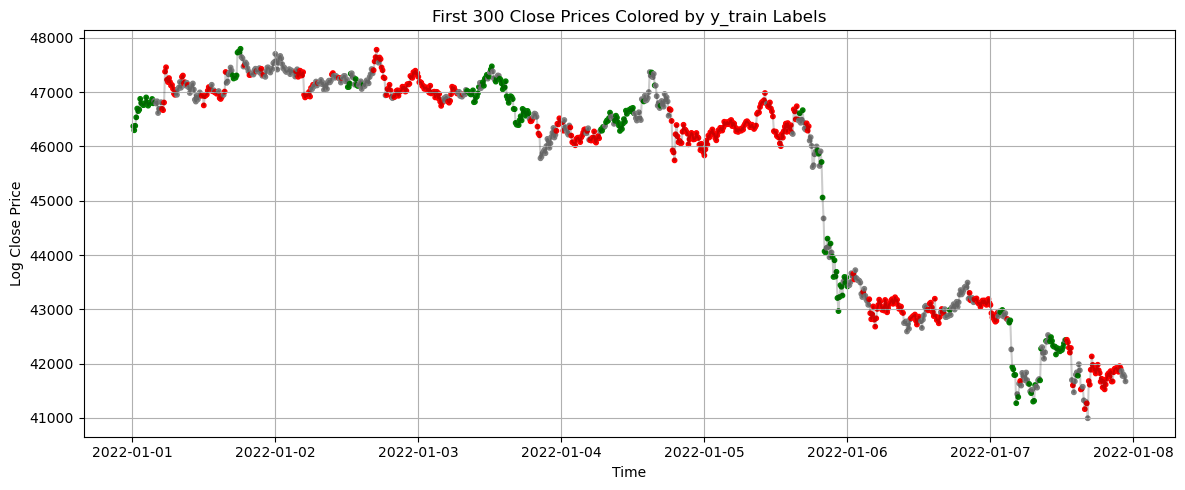

In [320]:
import matplotlib.pyplot as plt
import pandas as pd

# Select the first 300 samples
close_subset = close_10min.iloc[:1000]
y_subset = pd.Series(y_train[:1000], index=close_subset.index)

# Define color map: -1 = red, 0 = gray, 1 = green
color_map = {-0: 'red', 1: 'gray', 2: 'green'}
colors = y_subset.map(color_map)

# Plot
plt.figure(figsize=(12, 5))
plt.scatter(close_subset.index, close_subset.values, c=colors, s=10, label='close')
plt.plot(close_subset.index, close_subset.values, alpha=0.2, color='black')  # faint line for structure
plt.title('First 300 Close Prices Colored by y_train Labels')
plt.xlabel('Time')
plt.ylabel('Log Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()


<Axes: xlabel='time'>

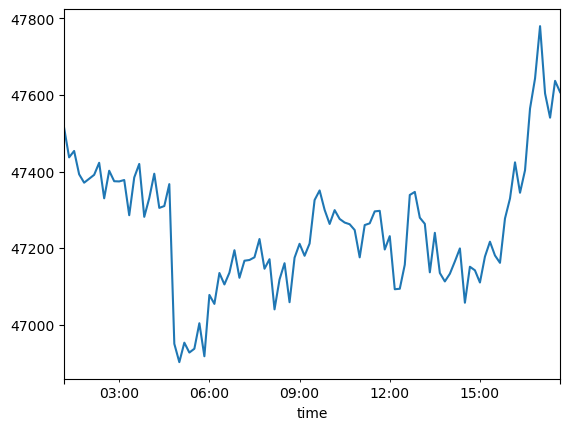

In [236]:
close_10min[150:250].plot()

In [187]:
pred_proba_df = pd.DataFrame(clf.predict_proba(X_test), columns=clf.classes_)
pred_proba_df['pred'] = y_pred
pred_proba_df['true'] = y_test
pred_proba_df

,-1,0,1,pred,true
0,0.348337,0.337153,0.314510,0,0
1,0.340694,0.342793,0.316513,0,0
2,0.350231,0.333191,0.316578,-1,0
3,0.351901,0.332797,0.315302,-1,0
4,0.338856,0.343976,0.317168,0,0
...,...,...,...,...,...
18475,0.320173,0.350784,0.329043,0,0
18476,0.321413,0.348587,0.329999,0,0
18477,0.321433,0.349427,0.329140,0,0
18478,0.320404,0.349434,0.330162,0,0


In [202]:
print("clf:", clf)
print("Is clf fitted?", hasattr(clf, "classes_"))


clf: RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)
Is clf fitted? True


In [206]:
np.isnan(y_calib).any()

False

In [209]:
from sklearn.calibration import CalibratedClassifierCV

# 3. Use in calibration
calibrator = CalibratedClassifierCV(
    base_estimator=clf,
    method='isotonic',
    cv='prefit'
)

calibrator.fit(X_calib_trans, y_calib)


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\calibration.py:300: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


TypeError: None is not an estimator instance.

In [166]:
import numpy as np
import pandas as pd

# 1. Get predicted class probabilities
probas = clf.predict_proba(X_test)  # shape: (n_samples, n_classes)
classes = clf.classes_              # e.g., [-1, 0, 1]
n_classes = len(classes)

# 2. Define a small jump penalty matrix
jump_penalty = -0.01
penalty_matrix = np.ones((n_classes, n_classes)) * jump_penalty
np.fill_diagonal(penalty_matrix, 0.0)  # no penalty for staying in the same class

# 3. Apply soft jump-penalized prediction using argmax
preds = []
prev_class_idx = None

for i, prob in enumerate(probas):
    if prev_class_idx is None:
        # First prediction — no penalty
        class_idx = np.argmax(prob)
    else:
        # Penalize jumping from previous class
        penalized_prob = prob - penalty_matrix[prev_class_idx]
        class_idx = np.argmax(penalized_prob)

    preds.append(classes[class_idx])
    prev_class_idx = class_idx

# 4. Wrap results in a DataFrame
pred_proba_df = pd.DataFrame(probas, columns=classes)
pred_proba_df['pred'] = preds
pred_proba_df['true'] = y_test  # assumes y_test is a NumPy array


In [167]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          -1       0.14      0.24      0.18      2161
           0       0.82      0.53      0.65     14098
           1       0.15      0.39      0.22      2221

    accuracy                           0.48     18480
   macro avg       0.37      0.39      0.35     18480
weighted avg       0.66      0.48      0.54     18480



##### XGBOOST

In [215]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

y_train_mapped = np.vectorize(label_map.get)(y_train)
y_test_mapped = np.vectorize(label_map.get)(y_test)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'objective': 'multi:softprob',
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_jobs': -1,
    }

    model = XGBClassifier(**params)
    tscv = TimeSeriesSplit(n_splits=5)
    scores = cross_val_score(model, X_train, y_train_mapped, cv=tscv, scoring='f1_weighted')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, timeout=300)  # Run for 30 trials or 10 mins

best_params = study.best_params
best_params.update({
    'objective': 'multi:softprob',
    'use_label_encoder': False,
    'eval_metric': 'mlogloss',
    'random_state': 42,
    'n_jobs': -1,
})

best_model = XGBClassifier(**best_params)
best_model.fit(X_train, y_train_mapped)

y_pred_mapped = best_model.predict(X_test)
y_pred = np.vectorize(inverse_label_map.get)(y_pred_mapped)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))



[I 2025-05-04 20:39:27,786] A new study created in memory with name: no-name-559f6ddf-23e6-486b-81b1-9b51c67a2f6a
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\xgboost\core.py:158: UserWarning: [20:39:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\xgboost\core.py:158: UserWarning: [20:40:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\xgboost\core.py:158: UserWarning: [20:41:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci

              precision    recall  f1-score   support

          -1       0.24      0.41      0.31      3904
           0       0.72      0.43      0.54     10583
           1       0.27      0.37      0.31      3986

    accuracy                           0.41     18473
   macro avg       0.41      0.40      0.38     18473
weighted avg       0.52      0.41      0.44     18473



In [217]:
best_params

{'n_estimators': 54,
 'max_depth': 12,
 'learning_rate': 0.05352860520997059,
 'subsample': 0.6285605144619916,
 'colsample_bytree': 0.8086225225216328,
 'objective': 'multi:softprob',
 'use_label_encoder': False,
 'eval_metric': 'mlogloss',
 'random_state': 42,
 'n_jobs': -1}

In [205]:
best_model = XGBClassifier(**best_params)
best_model.fit(X_train, y_train_mapped)

y_pred_mapped = best_model.predict(X_test)
y_pred = np.vectorize(inverse_label_map.get)(y_pred_mapped)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

NameError: name 'best_params' is not defined

### gridsearch

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, shuffle=False
# )

# y_train_mapped = np.vectorize(label_map.get)(y_train)
# y_test_mapped = np.vectorize(label_map.get)(y_test)



# tscv = TimeSeriesSplit(n_splits=5)

# grid_search = GridSearchCV(
#     estimator=XGBClassifier(
#         objective='multi:softprob',
#         use_label_encoder=False,
#         eval_metric='mlogloss',
#         random_state=42,
#         n_jobs=-1
#     ),
#     param_grid={
#         'n_estimators': [100, 300],
#         'max_depth': [3, 6],
#         'learning_rate': [0.01, 0.05]
#     },
#     scoring='f1_weighted',
#     cv=tscv,
#     verbose=1
# )

# grid_search.fit(X_train, y_train_mapped)

# best_model = grid_search.best_estimator_
# y_pred_mapped = best_model.predict(X_test)
# y_pred = np.vectorize(inverse_label_map.get)(y_pred_mapped)

# from sklearn.metrics import classification_report
# print(classification_report(y_test, y_pred))



In [127]:
# from sklearn.utils import resample
# import pandas as pd

# Xy_train = pd.DataFrame(X_train)
# Xy_train['label'] = y_train

# # Upsample classes -1 and 1
# major = Xy_train[Xy_train['label'] == 0]
# minor_1 = resample(Xy_train[Xy_train['label'] == -1], replace=True, n_samples=len(major)//3, random_state=42)
# minor_2 = resample(Xy_train[Xy_train['label'] == 1], replace=True, n_samples=len(major)//3, random_state=42)

# # Combine and shuffle
# Xy_bal = pd.concat([major, minor_1, minor_2]).sample(frac=1, random_state=42)
# X_train_bal = Xy_bal.drop(columns=['label']).values
# y_train_bal = Xy_bal['label'].values

# # Re-train
# clf.fit(X_train_bal, y_train_bal)
# y_pred = clf.predict(X_test)
# print(classification_report(y_test, y_pred))


### Finlab

In [13]:
"""
Contains the logic from chapter 20 on multiprocessing and vectorization.
"""

import sys
import time
import datetime as dt

import multiprocessing as mp

import numpy as np
import pandas as pd


# Snippet 20.5 (page 306), the lin_parts function
def lin_parts(num_atoms, num_threads):
    """
    Advances in Financial Machine Learning, Snippet 20.5, page 306.

    The lin_parts function

    The simplest way to form molecules is to partition a list of atoms in subsets of equal size,
    where the number of subsets is the minimum between the number of processors and the number
    of atoms. For N subsets we need to find the N+1 indices that enclose the partitions.
    This logic is demonstrated in Snippet 20.5.

    This function partitions a list of atoms in subsets (molecules) of equal size.
    An atom is a set of indivisible set of tasks.

    :param num_atoms: (int) Number of atoms
    :param num_threads: (int) Number of processors
    :return: (np.array) Partition of atoms
    """
    # Partition of atoms with a single loop
    parts = np.linspace(0, num_atoms, min(num_threads, num_atoms) + 1)
    parts = np.ceil(parts).astype(int)
    return parts


# Snippet 20.6 (page 308), The nested_parts function
def nested_parts(num_atoms, num_threads, upper_triangle=False):
    """
    Advances in Financial Machine Learning, Snippet 20.6, page 308.

    The nested_parts function

    This function enables parallelization of nested loops.
    :param num_atoms: (int) Number of atoms
    :param num_threads: (int) Number of processors
    :param upper_triangle: (bool) Flag to order atoms as an upper triangular matrix (including the main diagonal)
    :return: (np.array) Partition of atoms
    """
    # Partition of atoms with an inner loop
    parts = [0]
    num_threads_ = min(num_threads, num_atoms)

    for _ in range(num_threads_):
        part = 1 + 4 * (parts[-1] ** 2 + parts[-1] + num_atoms * (num_atoms + 1.0) / num_threads_)
        part = (-1 + part ** 0.5) / 2.0
        parts.append(part)

    parts = np.round(parts).astype(int)

    if upper_triangle:  # The first rows are heaviest
        parts = np.cumsum(np.diff(parts)[::-1])
        parts = np.append(np.array([0]), parts)

    return parts


# Snippet 20.7 (page 310), The mpPandasObj, used at various points in the book
def mp_pandas_obj(func, pd_obj, num_threads=24, mp_batches=1, lin_mols=True, verbose=True, **kargs):
    """
    Advances in Financial Machine Learning, Snippet 20.7, page 310.

    The mpPandasObj, used at various points in the book

    Parallelize jobs, return a dataframe or series.
    Example: df1=mp_pandas_obj(func,('molecule',df0.index),24,**kwds)

    First, atoms are grouped into molecules, using linParts (equal number of atoms per molecule)
    or nestedParts (atoms distributed in a lower-triangular structure). When mpBatches is greater
    than 1, there will be more molecules than cores. Suppose that we divide a task into 10 molecules,
    where molecule 1 takes twice as long as the rest. If we run this process in 10 cores, 9 of the
    cores will be idle half of the runtime, waiting for the first core to process molecule 1.
    Alternatively, we could set mpBatches=10 so as to divide that task in 100 molecules. In doing so,
    every core will receive equal workload, even though the first 10 molecules take as much time as the
    next 20 molecules. In this example, the run with mpBatches=10 will take half of the time consumed by
    mpBatches=1.

    Second, we form a list of jobs. A job is a dictionary containing all the information needed to process
    a molecule, that is, the callback function, its keyword arguments, and the subset of atoms that form
    the molecule.

    Third, we will process the jobs sequentially if numThreads==1 (see Snippet 20.8), and in parallel
    otherwise (see Section 20.5.2). The reason that we want the option to run jobs sequentially is for
    debugging purposes. It is not easy to catch a bug when programs are run in multiple processors.
    Once the code is debugged, we will want to use numThreads>1.

    Fourth, we stitch together the output from every molecule into a single list, series, or dataframe.

    :param func: (function) A callback function, which will be executed in parallel
    :param pd_obj: (tuple) Element 0: The name of the argument used to pass molecules to the callback function
                    Element 1: A list of indivisible tasks (atoms), which will be grouped into molecules
    :param num_threads: (int) The number of threads that will be used in parallel (one processor per thread)
    :param mp_batches: (int) Number of parallel batches (jobs per core)
    :param lin_mols: (bool) Tells if the method should use linear or nested partitioning
    :param verbose: (bool) Flag to report progress on asynch jobs
    :param kargs: (var args) Keyword arguments needed by func
    :return: (pd.DataFrame) of results
    """

    if lin_mols:
        parts = lin_parts(len(pd_obj[1]), num_threads * mp_batches)
    else:
        parts = nested_parts(len(pd_obj[1]), num_threads * mp_batches)

    jobs = []
    for i in range(1, len(parts)):
        job = {pd_obj[0]: pd_obj[1][parts[i - 1]:parts[i]], 'func': func}
        job.update(kargs)
        jobs.append(job)

    if num_threads == 1:
        out = process_jobs_(jobs)
    else:
        out = process_jobs(jobs, num_threads=num_threads, verbose=verbose)

    if isinstance(out[0], pd.DataFrame):
        df0 = pd.DataFrame()
    elif isinstance(out[0], pd.Series):
        df0 = pd.Series(dtype='float64')
    else:
        return out

    for i in out:
        df0 = pd.concat([df0, i])

    df0 = df0.sort_index()
    return df0


# Snippet 20.8, pg 311, Single thread execution, for debugging
def process_jobs_(jobs):
    """
    Advances in Financial Machine Learning, Snippet 20.8, page 311.

    Single thread execution, for debugging

    Run jobs sequentially, for debugging

    :param jobs: (list) Jobs (molecules)
    :return: (list) Results of jobs
    """
    out = []
    for job in jobs:
        out_ = expand_call(job)
        out.append(out_)

    return out


# Snippet 20.10 Passing the job (molecule) to the callback function
def expand_call(kargs):
    """
    Advances in Financial Machine Learning, Snippet 20.10.

    Passing the job (molecule) to the callback function

    Expand the arguments of a callback function, kargs['func']

    :param kargs: Job (molecule)
    :return: Result of a job
    """
    func = kargs['func']
    del kargs['func']
    out = func(**kargs)
    return out


# Snippet 20.9.1, pg 312, Example of Asynchronous call to pythons multiprocessing library
def report_progress(job_num, num_jobs, time0, task):
    """
    Advances in Financial Machine Learning, Snippet 20.9.1, pg 312.

    Example of Asynchronous call to pythons multiprocessing library

    :param job_num: (int) Number of current job
    :param num_jobs: (int) Total number of jobs
    :param time0: (time) Start time
    :param task: (str) Task description
    :return: (None)
    """
    # Report progress as asynch jobs are completed
    msg = [float(job_num) / num_jobs, (time.time() - time0) / 60.0]
    msg.append(msg[1] * (1 / msg[0] - 1))
    time_stamp = str(dt.datetime.fromtimestamp(time.time()))

    msg = time_stamp + ' ' + str(round(msg[0] * 100, 2)) + '% ' + task + ' done after ' + \
          str(round(msg[1], 2)) + ' minutes. Remaining ' + str(round(msg[2], 2)) + ' minutes.'

    if job_num < num_jobs:
        sys.stderr.write(msg + '\r')
    else:
        sys.stderr.write(msg + '\n')


# Snippet 20.9.2, pg 312, Example of Asynchronous call to pythons multiprocessing library
def process_jobs(jobs, task=None, num_threads=24, verbose=True):
    """
    Advances in Financial Machine Learning, Snippet 20.9.2, page 312.

    Example of Asynchronous call to pythons multiprocessing library

    Run in parallel. jobs must contain a 'func' callback, for expand_call

    :param jobs: (list) Jobs (molecules)
    :param task: (str) Task description
    :param num_threads: (int) The number of threads that will be used in parallel (one processor per thread)
    :param verbose: (bool) Flag to report progress on asynch jobs
    :return: (None)
    """

    if task is None:
        task = jobs[0]['func'].__name__

    pool = mp.Pool(processes=num_threads)
    outputs = pool.imap_unordered(expand_call, jobs)
    out = []
    time0 = time.time()

    # Process asynchronous output, report progress
    for i, out_ in enumerate(outputs, 1):
        out.append(out_)
        if verbose:
            report_progress(i, len(jobs), time0, task)

    pool.close()
    pool.join()  # This is needed to prevent memory leaks
    return out
"""
Logic regarding labeling from chapter 3. In particular the Triple Barrier Method and Meta-Labeling.
"""

import numpy as np
import pandas as pd

# Snippet 3.1, page 44, Daily Volatility Estimates
# from mlfinlab.util.multiprocess import mp_pandas_obj


# Snippet 3.2, page 45, Triple Barrier Labeling Method
def apply_pt_sl_on_t1(close, events, pt_sl, molecule):  # pragma: no cover
    """
    Advances in Financial Machine Learning, Snippet 3.2, page 45.

    Triple Barrier Labeling Method

    This function applies the triple-barrier labeling method. It works on a set of
    datetime index values (molecule). This allows the program to parallelize the processing.

    Mainly it returns a DataFrame of timestamps regarding the time when the first barriers were reached.

    :param close: (pd.Series) Close prices
    :param events: (pd.Series) Indices that signify "events" (see cusum_filter function
    for more details)
    :param pt_sl: (np.array) Element 0, indicates the profit taking level; Element 1 is stop loss level
    :param molecule: (an array) A set of datetime index values for processing
    :return: (pd.DataFrame) Timestamps of when first barrier was touched
    """
    # Apply stop loss/profit taking, if it takes place before t1 (end of event)
    events_ = events.loc[molecule]
    out = events_[['t1']].copy(deep=True)

    profit_taking_multiple = pt_sl[0]
    stop_loss_multiple = pt_sl[1]

    # Profit taking active
    if profit_taking_multiple > 0:
        profit_taking = profit_taking_multiple * events_['trgt']
    else:
        profit_taking = pd.Series(index=events.index)  # NaNs

    # Stop loss active
    if stop_loss_multiple > 0:
        stop_loss = -stop_loss_multiple * events_['trgt']
    else:
        stop_loss = pd.Series(index=events.index)  # NaNs

    out['pt'] = pd.Series(dtype=events.index.dtype)
    out['sl'] = pd.Series(dtype=events.index.dtype)

    # Get events
    for loc, vertical_barrier in events_['t1'].fillna(close.index[-1]).items():
        closing_prices = close[loc: vertical_barrier]  # Path prices for a given trade
        cum_returns = (closing_prices / close[loc] - 1) * events_.at[loc, 'side']  # Path returns
        out.at[loc, 'sl'] = cum_returns[cum_returns < stop_loss[loc]].index.min()  # Earliest stop loss date
        out.at[loc, 'pt'] = cum_returns[cum_returns > profit_taking[loc]].index.min()  # Earliest profit taking date

    return out


# Snippet 3.4 page 49, Adding a Vertical Barrier
def add_vertical_barrier(t_events, close, num_days=0, num_hours=0, num_minutes=0, num_seconds=0):
    """
    Advances in Financial Machine Learning, Snippet 3.4 page 49.

    Adding a Vertical Barrier

    For each index in t_events, it finds the timestamp of the next price bar at or immediately after
    a number of days num_days. This vertical barrier can be passed as an optional argument t1 in get_events.

    This function creates a series that has all the timestamps of when the vertical barrier would be reached.

    :param t_events: (pd.Series) Series of events (symmetric CUSUM filter)
    :param close: (pd.Series) Close prices
    :param num_days: (int) Number of days to add for vertical barrier
    :param num_hours: (int) Number of hours to add for vertical barrier
    :param num_minutes: (int) Number of minutes to add for vertical barrier
    :param num_seconds: (int) Number of seconds to add for vertical barrier
    :return: (pd.Series) Timestamps of vertical barriers
    """
    timedelta = pd.Timedelta(
        '{} days, {} hours, {} minutes, {} seconds'.format(num_days, num_hours, num_minutes, num_seconds))
    # Find index to closest to vertical barrier
    nearest_index = close.index.searchsorted(t_events + timedelta)

    # Exclude indexes which are outside the range of close price index
    nearest_index = nearest_index[nearest_index < close.shape[0]]

    # Find price index closest to vertical barrier time stamp
    nearest_timestamp = close.index[nearest_index]
    filtered_events = t_events[:nearest_index.shape[0]]

    vertical_barriers = pd.Series(data=nearest_timestamp, index=filtered_events)
    return vertical_barriers


# Snippet 3.3 -> 3.6 page 50, Getting the Time of the First Touch, with Meta Labels
def get_events(close, t_events, pt_sl, target, min_ret, num_threads, vertical_barrier_times=False,
               side_prediction=None, verbose=True):
    """
    Advances in Financial Machine Learning, Snippet 3.6 page 50.

    Getting the Time of the First Touch, with Meta Labels

    This function is orchestrator to meta-label the data, in conjunction with the Triple Barrier Method.

    :param close: (pd.Series) Close prices
    :param t_events: (pd.Series) of t_events. These are timestamps that will seed every triple barrier.
        These are the timestamps selected by the sampling procedures discussed in Chapter 2, Section 2.5.
        Eg: CUSUM Filter
    :param pt_sl: (2 element array) Element 0, indicates the profit taking level; Element 1 is stop loss level.
        A non-negative float that sets the width of the two barriers. A 0 value means that the respective
        horizontal barrier (profit taking and/or stop loss) will be disabled.
    :param target: (pd.Series) of values that are used (in conjunction with pt_sl) to determine the width
        of the barrier. In this program this is daily volatility series.
    :param min_ret: (float) The minimum target return required for running a triple barrier search.
    :param num_threads: (int) The number of threads concurrently used by the function.
    :param vertical_barrier_times: (pd.Series) A pandas series with the timestamps of the vertical barriers.
        We pass a False when we want to disable vertical barriers.
    :param side_prediction: (pd.Series) Side of the bet (long/short) as decided by the primary model
    :param verbose: (bool) Flag to report progress on asynch jobs
    :return: (pd.DataFrame) Events
            -events.index is event's starttime
            -events['t1'] is event's endtime
            -events['trgt'] is event's target
            -events['side'] (optional) implies the algo's position side
            -events['pt'] is profit taking multiple
            -events['sl']  is stop loss multiple
    """

    # 1) Get target
    target = target.reindex(t_events)
    target = target[target > min_ret]  # min_ret

    # 2) Get vertical barrier (max holding period)
    if vertical_barrier_times is False:
        vertical_barrier_times = pd.Series(pd.NaT, index=t_events, dtype=t_events.dtype)

    # 3) Form events object, apply stop loss on vertical barrier
    if side_prediction is None:
        side_ = pd.Series(1.0, index=target.index)
        pt_sl_ = [pt_sl[0], pt_sl[0]]
    else:
        side_ = side_prediction.reindex(target.index)  # Subset side_prediction on target index.
        pt_sl_ = pt_sl[:2]

    # Create a new df with [v_barrier, target, side] and drop rows that are NA in target
    events = pd.concat({'t1': vertical_barrier_times, 'trgt': target, 'side': side_}, axis=1)
    events = events.dropna(subset=['trgt'])

    # Apply Triple Barrier
    first_touch_dates = mp_pandas_obj(func=apply_pt_sl_on_t1,
                                      pd_obj=('molecule', events.index),
                                      num_threads=num_threads,
                                      close=close,
                                      events=events,
                                      pt_sl=pt_sl_,
                                      verbose=verbose)

    for ind in events.index:
        events.at[ind, 't1'] = first_touch_dates.loc[ind, :].dropna().min()

    if side_prediction is None:
        events = events.drop('side', axis=1)

    # Add profit taking and stop loss multiples for vertical barrier calculations
    events['pt'] = pt_sl[0]
    events['sl'] = pt_sl[1]

    return events


# Snippet 3.9, pg 55, Question 3.3
def barrier_touched(out_df, events):
    """
    Advances in Financial Machine Learning, Snippet 3.9, page 55, Question 3.3.

    Adjust the getBins function (Snippet 3.7) to return a 0 whenever the vertical barrier is the one touched first.

    Top horizontal barrier: 1
    Bottom horizontal barrier: -1
    Vertical barrier: 0

    :param out_df: (pd.DataFrame) Returns and target
    :param events: (pd.DataFrame) The original events data frame. Contains the pt sl multiples needed here.
    :return: (pd.DataFrame) Returns, target, and labels
    """
    store = []
    for date_time, values in out_df.iterrows():
        ret = values['ret']
        target = values['trgt']

        pt_level_reached = ret > np.log(1 + target) * events.loc[date_time, 'pt']
        sl_level_reached = ret < -np.log(1 + target) * events.loc[date_time, 'sl']

        if ret > 0.0 and pt_level_reached:
            # Top barrier reached
            store.append(1)
        elif ret < 0.0 and sl_level_reached:
            # Bottom barrier reached
            store.append(-1)
        else:
            # Vertical barrier reached
            store.append(0)

    # Save to 'bin' column and return
    out_df['bin'] = store
    return out_df


# Snippet 3.4 -> 3.7, page 51, Labeling for Side & Size with Meta Labels
def get_bins(triple_barrier_events, close):
    """
    Advances in Financial Machine Learning, Snippet 3.7, page 51.

    Labeling for Side & Size with Meta Labels

    Compute event's outcome (including side information, if provided).
    events is a DataFrame where:

    Now the possible values for labels in out['bin'] are {0,1}, as opposed to whether to take the bet or pass,
    a purely binary prediction. When the predicted label the previous feasible values {−1,0,1}.
    The ML algorithm will be trained to decide is 1, we can use the probability of this secondary prediction
    to derive the size of the bet, where the side (sign) of the position has been set by the primary model.

    :param triple_barrier_events: (pd.DataFrame)
                -events.index is event's starttime
                -events['t1'] is event's endtime
                -events['trgt'] is event's target
                -events['side'] (optional) implies the algo's position side
                Case 1: ('side' not in events): bin in (-1,1) <-label by price action
                Case 2: ('side' in events): bin in (0,1) <-label by pnl (meta-labeling)
    :param close: (pd.Series) Close prices
    :return: (pd.DataFrame) Meta-labeled events
    """

    # 1) Align prices with their respective events
    events_ = triple_barrier_events.dropna(subset=['t1'])
    all_dates = events_.index.union(other=events_['t1'].array).drop_duplicates()
    prices = close.reindex(all_dates, method='bfill')

    # 2) Create out DataFrame
    out_df = pd.DataFrame(index=events_.index)
    # Need to take the log returns, else your results will be skewed for short positions
    out_df['ret'] = np.log(prices.loc[events_['t1'].array].array) - np.log(prices.loc[events_.index])
    out_df['trgt'] = events_['trgt']

    # Meta labeling: Events that were correct will have pos returns
    if 'side' in events_:
        out_df['ret'] = out_df['ret'] * events_['side']  # meta-labeling

    # Added code: label 0 when vertical barrier reached
    out_df = barrier_touched(out_df, triple_barrier_events)

    # Meta labeling: label incorrect events with a 0
    if 'side' in events_:
        out_df.loc[out_df['ret'] <= 0, 'bin'] = 0

    # Transform the log returns back to normal returns.
    out_df['ret'] = np.exp(out_df['ret']) - 1

    # Add the side to the output. This is useful for when a meta label model must be fit
    tb_cols = triple_barrier_events.columns
    if 'side' in tb_cols:
        out_df['side'] = triple_barrier_events['side']

    return out_df


# Snippet 3.8 page 54
def drop_labels(events, min_pct=.05):
    """
    Advances in Financial Machine Learning, Snippet 3.8 page 54.

    This function recursively eliminates rare observations.

    :param events: (dp.DataFrame) Events.
    :param min_pct: (float) A fraction used to decide if the observation occurs less than that fraction.
    :return: (pd.DataFrame) Events.
    """
    # Apply weights, drop labels with insufficient examples
    while True:
        df0 = events['bin'].value_counts(normalize=True)

        if df0.min() > min_pct or df0.shape[0] < 3:
            break

        print('dropped label: ', df0.idxmin(), df0.min())
        events = events[events['bin'] != df0.idxmin()]

    return events